# Remote Community Connectivity Priority Analysis

Two EWM rankings are calculated:
- **Ranking 1:** Connectivity Priority
- **Ranking 2:** Connectivity + Population Priority


## 1. Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## 2. Load Dataset


In [2]:
data = pd.read_csv("remote_community_connectivity_data.csv")

print("Dataset shape:", data.shape)
data.head()


Dataset shape: (792, 31)


,community_id,community_name,community_type,community_latitude,community_longitude,population_final,nearest_tower_state,nearest_tower_id,nearest_tower_name,distance_community_to_tower_km,...,nearest_mobile_site_objectid,nearest_mobile_site_rfnsa_id,nearest_mobile_site_mno,nearest_mobile_site_year,nearest_mobile_site_latitude,nearest_mobile_site_longitude,nearest_mobile_site_has_4g,nearest_mobile_site_has_5g,nbn_fixed_wireless_coverage,nbn_fixed_line_coverage
0,1022,10 MILE,Family Outstation,-20.40628,134.75934,8.0,NT,53061,Panjirriji TENNANT CREEK,28.23,...,9615,872166,Telstra,2025,-20.446391,135.261765,Yes,No,No,No
1,1004,10 MILE OUTSTATION,Family Outstation,-22.46667,132.37658,10.0,NT,10009413,"Camp 1 Tanami Pipeline Tanami Rd, 72 km SE of ...",19.58,...,9623,872177,Telstra,2025,-22.258348,132.205041,Yes,No,No,No
2,783,16 MILE CAMP,Family Outstation,-23.45764,133.83248,NaN,NT,10033488,"MarchNet Site Burt Plain, 18247 Stuart Highway...",2.39,...,9559,870010,Telstra,2025,-23.523950,133.680870,Yes,No,No,No
3,24993,20 MILE,Family Outstation,-16.08535,136.54826,6.0,NT,2231,Telstra Radio Terminal 32 km ESE of Borroloola...,13.49,...,9547,854001,Telstra,2025,-16.053610,136.306110,Yes,No,No,No
4,1006,4 MILE CAMP,Family Outstation,-11.77798,130.59548,7.0,NT,10003079,Airport Lighting Room Bathurst Island Airport ...,2.85,...,9442,822025,Telstra,2025,-11.756390,130.636940,Yes,No,No,No


## 3. Data Overview


In [3]:
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])
data.info()


Number of rows: 792
Number of columns: 31
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 792 entries, 0 to 791
Data columns (total 31 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   community_id                            792 non-null    int64  
 1   community_name                          792 non-null    object 
 2   community_type                          792 non-null    object 
 3   community_latitude                      792 non-null    float64
 4   community_longitude                     792 non-null    float64
 5   population_final                        468 non-null    float64
 6   nearest_tower_state                     792 non-null    object 
 7   nearest_tower_id                        792 non-null    int64  
 8   nearest_tower_name                      792 non-null    object 
 9   distance_community_to_tower_km          792 non-null    float64
 10  nearest_wifi_id     

In [4]:
data.columns.tolist()


['community_id',
 'community_name',
 'community_type',
 'community_latitude',
 'community_longitude',
 'population_final',
 'nearest_tower_state',
 'nearest_tower_id',
 'nearest_tower_name',
 'distance_community_to_tower_km',
 'nearest_wifi_id',
 'nearest_wifi_address',
 'distance_community_to_wifi_km',
 'mobile_outdoor_coverage_telstra',
 'mobile_outdoor_coverage_optus',
 'mobile_outdoor_coverage_tpg',
 'mobile_outdoor_coverage_tpg_on_optus',
 'mobile_outdoor_coverage_any_network',
 'mobile_4g_outdoor_coverage_any_network',
 'mobile_5g_outdoor_coverage_any_network',
 'nearest_mobile_site_distance_km',
 'nearest_mobile_site_objectid',
 'nearest_mobile_site_rfnsa_id',
 'nearest_mobile_site_mno',
 'nearest_mobile_site_year',
 'nearest_mobile_site_latitude',
 'nearest_mobile_site_longitude',
 'nearest_mobile_site_has_4g',
 'nearest_mobile_site_has_5g',
 'nbn_fixed_wireless_coverage',
 'nbn_fixed_line_coverage']

## 4. Missing Values


In [5]:
missing = pd.DataFrame({
    "Missing": data.isna().sum(),
    "Missing_Percent": (data.isna().mean() * 100).round(2)
})

missing[missing["Missing"] > 0].sort_values("Missing", ascending=False)


,Missing,Missing_Percent
population_final,324,40.91


## 5. Duplicate Check


In [6]:
print("Duplicate rows:", data.duplicated().sum())
print("Duplicate community IDs:", data["community_id"].duplicated().sum())


Duplicate rows: 0
Duplicate community IDs: 0


## 6. Descriptive Statistics


In [7]:
numeric_features = [
    "nearest_mobile_site_distance_km",
    "distance_community_to_tower_km",
    "distance_community_to_wifi_km",
    "population_final"
]

data[numeric_features].describe().T


,count,mean,std,min,25%,50%,75%,max
nearest_mobile_site_distance_km,792.0,27.359482,27.601527,0.01,5.335,19.195,41.0150,154.56
distance_community_to_tower_km,792.0,8.730682,12.181272,0.01,0.270,4.515,12.7175,103.65
distance_community_to_wifi_km,792.0,113.778485,103.557448,0.04,33.815,84.795,174.3100,511.93
population_final,468.0,112.397436,325.804358,1.00,7.000,14.500,47.7500,3362.00


## 7. Connectivity Distribution


In [8]:
coverage_columns = [
    "mobile_outdoor_coverage_any_network",
    "mobile_4g_outdoor_coverage_any_network",
    "mobile_5g_outdoor_coverage_any_network",
    "nbn_fixed_line_coverage",
    "nbn_fixed_wireless_coverage"
]

for column in coverage_columns:
    print("\n", column)
    print(data[column].value_counts(dropna=False))



 mobile_outdoor_coverage_any_network
mobile_outdoor_coverage_any_network
No     442
Yes    350
Name: count, dtype: int64

 mobile_4g_outdoor_coverage_any_network
mobile_4g_outdoor_coverage_any_network
No     443
Yes    349
Name: count, dtype: int64

 mobile_5g_outdoor_coverage_any_network
mobile_5g_outdoor_coverage_any_network
No     739
Yes     53
Name: count, dtype: int64

 nbn_fixed_line_coverage
nbn_fixed_line_coverage
No     762
Yes     30
Name: count, dtype: int64

 nbn_fixed_wireless_coverage
nbn_fixed_wireless_coverage
No     791
Yes      1
Name: count, dtype: int64


## 8. Feature Engineering

Higher values represent greater connectivity need.


In [9]:
coverage_mapping = {"Yes": 0, "No": 1}

data["mobile_need"] = data["mobile_outdoor_coverage_any_network"].map(coverage_mapping)
data["mobile_4g_need"] = data["mobile_4g_outdoor_coverage_any_network"].map(coverage_mapping)
data["mobile_5g_need"] = data["mobile_5g_outdoor_coverage_any_network"].map(coverage_mapping)

data["nbn_need"] = np.where(
    (data["nbn_fixed_line_coverage"] == "Yes") |
    (data["nbn_fixed_wireless_coverage"] == "Yes"),
    0, 1
)

data[["mobile_need", "mobile_4g_need", "mobile_5g_need", "nbn_need"]].head()


,mobile_need,mobile_4g_need,mobile_5g_need,nbn_need
0,1,1,1,1
1,1,1,1,1
2,0,0,1,1
3,1,1,1,1
4,0,0,1,1


## 9. Candidate Features


In [10]:
candidate_features = [
    "mobile_need",
    "mobile_4g_need",
    "mobile_5g_need",
    "nbn_need",
    "nearest_mobile_site_distance_km",
    "distance_community_to_tower_km",
    "distance_community_to_wifi_km",
    "population_final"
]


## 10. Candidate Feature Assessment


In [11]:
feature_summary = pd.DataFrame({
    "Missing": data[candidate_features].isna().sum(),
    "Missing_Percent": (data[candidate_features].isna().mean() * 100).round(2),
    "Unique_Values": data[candidate_features].nunique(),
    "Variance": data[candidate_features].var()
})

feature_summary


,Missing,Missing_Percent,Unique_Values,Variance
mobile_need,0,0.00,2,0.246938
mobile_4g_need,0,0.00,2,0.246790
mobile_5g_need,0,0.00,2,0.062520
nbn_need,0,0.00,2,0.037657
nearest_mobile_site_distance_km,0,0.00,723,761.844304
distance_community_to_tower_km,0,0.00,546,148.383390
distance_community_to_wifi_km,0,0.00,775,10724.144999
population_final,324,40.91,144,106148.479822


## 11. Correlation Analysis


In [12]:
corr = data[candidate_features].corr()
corr.round(2)


,mobile_need,mobile_4g_need,mobile_5g_need,nbn_need,nearest_mobile_site_distance_km,distance_community_to_tower_km,distance_community_to_wifi_km,population_final
mobile_need,1.00,1.00,0.30,0.23,0.65,0.40,0.14,-0.27
mobile_4g_need,1.00,1.00,0.30,0.23,0.65,0.40,0.14,-0.27
mobile_5g_need,0.30,0.30,1.00,0.55,0.25,0.18,0.08,-0.35
nbn_need,0.23,0.23,0.55,1.00,0.19,0.14,0.06,-0.25
nearest_mobile_site_distance_km,0.65,0.65,0.25,0.19,1.00,0.54,0.28,-0.27
distance_community_to_tower_km,0.40,0.40,0.18,0.14,0.54,1.00,0.27,-0.23
distance_community_to_wifi_km,0.14,0.14,0.08,0.06,0.28,0.27,1.00,-0.01
population_final,-0.27,-0.27,-0.35,-0.25,-0.27,-0.23,-0.01,1.00


## 12. Correlation Heatmap


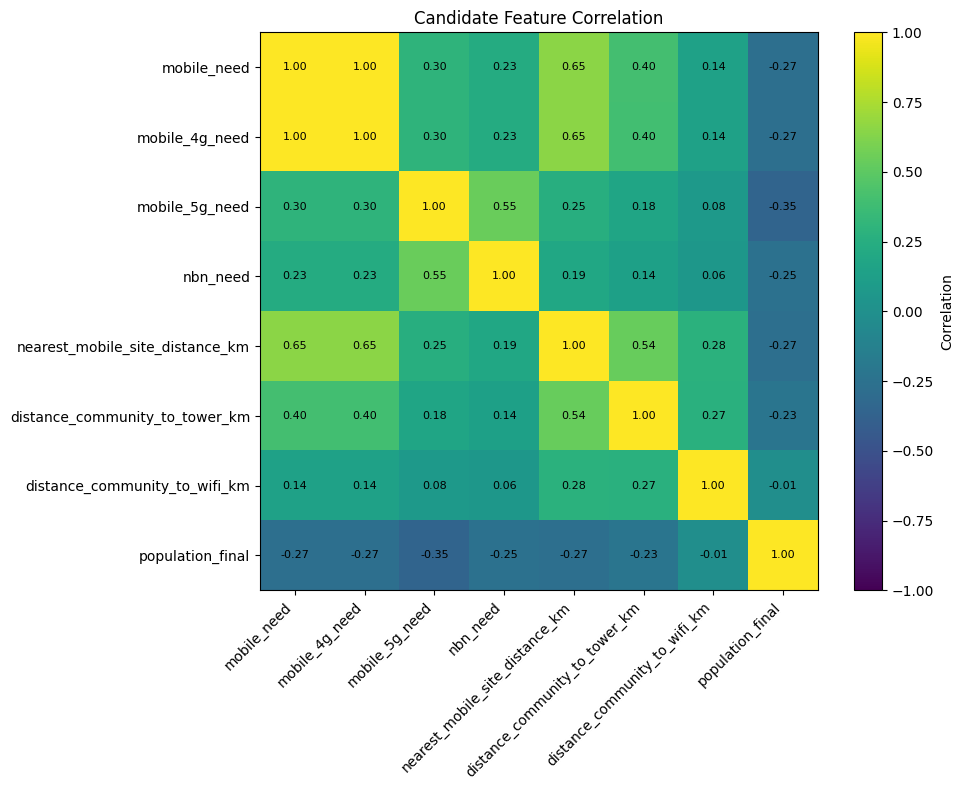

In [13]:
plt.figure(figsize=(10, 8))
plt.imshow(corr, vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks(range(len(candidate_features)), candidate_features, rotation=45, ha="right")
plt.yticks(range(len(candidate_features)), candidate_features)

for i in range(len(candidate_features)):
    for j in range(len(candidate_features)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.title("Candidate Feature Correlation")
plt.tight_layout()
plt.show()


## 13. Redundancy Check

Features with |r| ≥ 0.80 are flagged for review.


In [14]:
high_corr = []

for i in range(len(candidate_features)):
    for j in range(i + 1, len(candidate_features)):
        r = corr.iloc[i, j]
        if abs(r) >= 0.80:
            high_corr.append([
                candidate_features[i],
                candidate_features[j],
                round(r, 2)
            ])

high_corr = pd.DataFrame(
    high_corr,
    columns=["Feature_1", "Feature_2", "Correlation"]
)

high_corr


,Feature_1,Feature_2,Correlation
0,mobile_need,mobile_4g_need,1.0


## 14. Examine Key Relationships


In [15]:
mobile_4g_corr = corr.loc[
    "mobile_need",
    "mobile_4g_need"
]

print(
    "mobile_need vs mobile_4g_need:",
    round(mobile_4g_corr, 2)
)


mobile_need vs mobile_4g_need: 1.0


## 15. Feature Selection


In [16]:
feature_selection = pd.DataFrame({
    "Feature": [
        "mobile_need",
        "mobile_4g_need",
        "mobile_5g_need",
        "nbn_need",
        "nearest_mobile_site_distance_km",
        "distance_community_to_tower_km",
        "distance_community_to_wifi_km",
        "population_final"
    ],
    "Decision": [
        "Selected",
        "Excluded",
        "Excluded",
        "Selected",
        "Selected",
        "Excluded",
        "Selected",
        "Ranking 2"
    ],
    "Reason": [
        "Overall mobile coverage gap",
        f"Redundant with mobile_need (observed r = {mobile_4g_corr:.2f})",
        "Technology-specific rather than overall mobile coverage",
        "Overall NBN coverage gap",
        "Direct measure of mobile infrastructure proximity",
        "Excluded to avoid overlapping representation of mobile infrastructure proximity",
        "Represents Wi-Fi infrastructure proximity",
        "Used separately to represent potential population impact"
    ]
})

feature_selection


,Feature,Decision,Reason
0,mobile_need,Selected,Overall mobile coverage gap
1,mobile_4g_need,Excluded,Redundant with mobile_need (observed r = 1.00)
2,mobile_5g_need,Excluded,Technology-specific rather than overall mobile...
3,nbn_need,Selected,Overall NBN coverage gap
4,nearest_mobile_site_distance_km,Selected,Direct measure of mobile infrastructure proximity
5,distance_community_to_tower_km,Excluded,Excluded to avoid overlapping representation o...
6,distance_community_to_wifi_km,Selected,Represents Wi-Fi infrastructure proximity
7,population_final,Ranking 2,Used separately to represent potential populat...


## 16. Final Connectivity Indicators


In [17]:
connectivity_features = [
    "mobile_need",
    "nbn_need",
    "nearest_mobile_site_distance_km",
    "distance_community_to_wifi_km"
]

data[connectivity_features].head()


,mobile_need,nbn_need,nearest_mobile_site_distance_km,distance_community_to_wifi_km
0,1,1,52.54,147.31
1,1,1,29.12,94.88
2,0,1,17.13,27.52
3,1,1,26.11,25.84
4,0,1,5.11,74.98


## 17. Min-Max Normalisation


In [18]:
def normalize(series):
    minimum = series.min()
    maximum = series.max()

    if maximum == minimum:
        return pd.Series(0.0, index=series.index)

    return (series - minimum) / (maximum - minimum)


## 18. EWM Function


In [19]:
def run_ewm(df, features):
    result = df.copy()
    normalized_features = []

    for feature in features:
        new_col = feature + "_norm"
        result[new_col] = normalize(result[feature])
        normalized_features.append(new_col)

    X = result[normalized_features].copy()

    P = X.div(X.sum(axis=0), axis=1)

    n = len(X)
    k = 1 / np.log(n)

    P_safe = P.replace(0, np.nan)

    entropy = -k * (P_safe * np.log(P_safe)).sum(axis=0)
    divergence = 1 - entropy
    weights = divergence / divergence.sum()

    result["priority_score"] = (X.values * weights.values).sum(axis=1)

    result = result.sort_values(
        "priority_score",
        ascending=False
    ).reset_index(drop=True)

    result["priority_rank"] = result.index + 1

    weight_table = pd.DataFrame({
        "Feature": features,
        "Entropy": entropy.values,
        "Divergence": divergence.values,
        "Weight": weights.values
    })

    weight_table["Weight_Percent"] = (
        weight_table["Weight"] * 100
    ).round(2)

    return result, weight_table


# Ranking 1 — Connectivity Priority


## 19. Prepare Ranking 1


In [20]:
ranking1_data = data.dropna(subset=connectivity_features).copy()

print("Communities in Ranking 1:", len(ranking1_data))


Communities in Ranking 1: 792


## 20. Calculate Ranking 1


In [21]:
ranking1, weights1 = run_ewm(
    ranking1_data,
    connectivity_features
)


## 21. Ranking 1 EWM Weights


In [22]:
weights1


,Feature,Entropy,Divergence,Weight,Weight_Percent
0,mobile_need,0.912616,0.087384,0.388135,38.81
1,nbn_need,0.994018,0.005982,0.026571,2.66
2,nearest_mobile_site_distance_km,0.928015,0.071985,0.319738,31.97
3,distance_community_to_wifi_km,0.940213,0.059787,0.265557,26.56


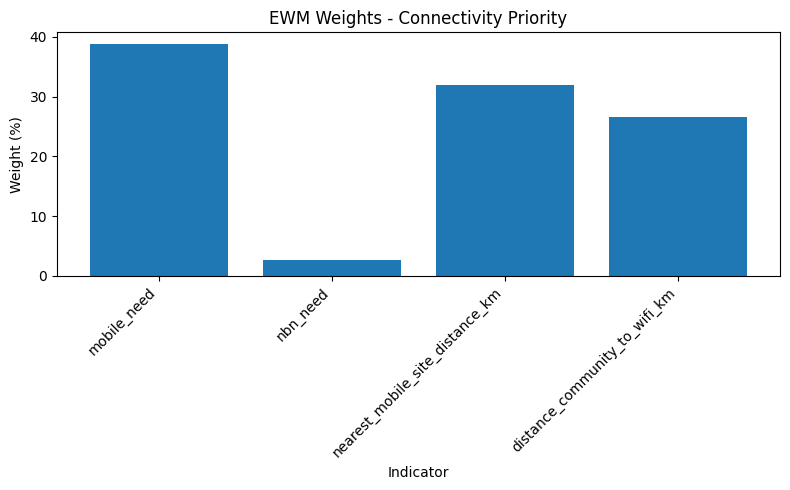

In [23]:
plt.figure(figsize=(8, 5))
plt.bar(weights1["Feature"], weights1["Weight_Percent"])
plt.title("EWM Weights - Connectivity Priority")
plt.xlabel("Indicator")
plt.ylabel("Weight (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 22. Ranking 1 Results


In [24]:
ranking1_results = ranking1[
    [
        "priority_rank",
        "community_id",
        "community_name",
        "mobile_need",
        "nbn_need",
        "nearest_mobile_site_distance_km",
        "distance_community_to_wifi_km",
        "priority_score"
    ]
]

ranking1_results.head(10)


,priority_rank,community_id,community_name,mobile_need,nbn_need,nearest_mobile_site_distance_km,distance_community_to_wifi_km,priority_score
0,1,176,WALYTJATJATA,1,1,128.74,395.12,0.885984
1,2,689,MURUN MURULA,1,1,150.22,299.09,0.880605
2,3,81,KURKUTJARA,1,1,123.46,395.63,0.875326
3,4,646,JIWARANPA,1,1,107.73,454.58,0.873365
4,5,160,UKATJUPU,1,1,115.33,413.44,0.867745
5,6,690,WANGALINJI,1,1,141.22,286.48,0.855443
6,7,694,MAMADI,1,1,110.63,404.92,0.853602
7,8,631,DUCK PONDS,1,1,83.79,482.79,0.838472
8,9,745,MIRRIDI,1,1,77.93,479.84,0.824818
9,10,25070,BATTON HILL,1,1,141.08,214.83,0.817983


## 23. Top 10 — Ranking 1


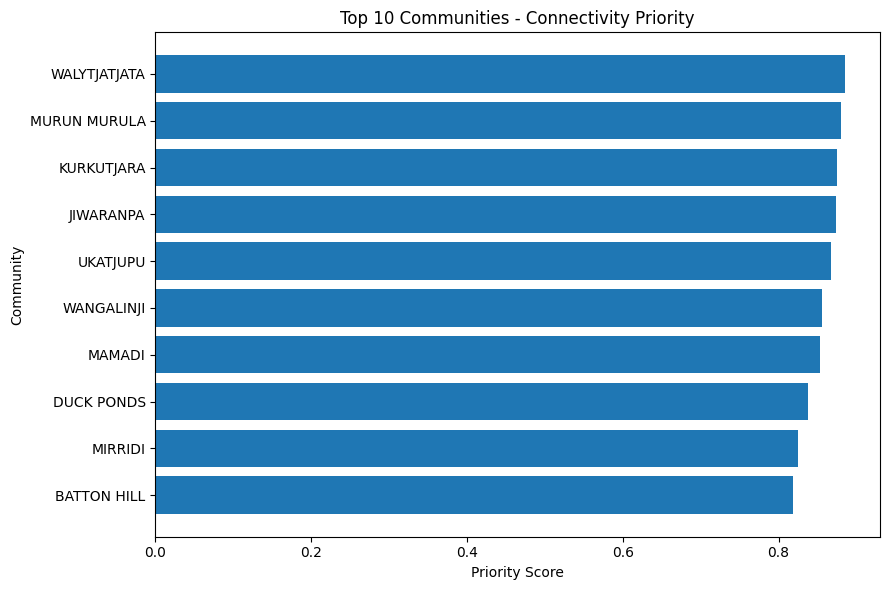

In [25]:
top10_ranking1 = ranking1_results.head(10).sort_values("priority_score")

plt.figure(figsize=(9, 6))
plt.barh(top10_ranking1["community_name"], top10_ranking1["priority_score"])
plt.title("Top 10 Communities - Connectivity Priority")
plt.xlabel("Priority Score")
plt.ylabel("Community")
plt.tight_layout()
plt.show()


# Ranking 2 — Connectivity + Population Priority


## 24. Prepare Ranking 2


In [26]:
ranking2_features = [
    "mobile_need",
    "nbn_need",
    "nearest_mobile_site_distance_km",
    "distance_community_to_wifi_km",
    "population_final"
]

ranking2_data = data.dropna(subset=ranking2_features).copy()

print("Communities in Ranking 1:", len(ranking1_data))
print("Communities in Ranking 2:", len(ranking2_data))
print("Population unavailable:", data["population_final"].isna().sum())


Communities in Ranking 1: 792
Communities in Ranking 2: 468
Population unavailable: 324


## 25. Calculate Ranking 2


In [27]:
ranking2, weights2 = run_ewm(
    ranking2_data,
    ranking2_features
)


## 26. Ranking 2 EWM Weights


In [28]:
weights2


,Feature,Entropy,Divergence,Weight,Weight_Percent
0,mobile_need,0.886569,0.113431,0.221375,22.14
1,nbn_need,0.997196,0.002804,0.005473,0.55
2,nearest_mobile_site_distance_km,0.920805,0.079195,0.154559,15.46
3,distance_community_to_wifi_km,0.938350,0.061650,0.120318,12.03
4,population_final,0.744686,0.255314,0.498275,49.83


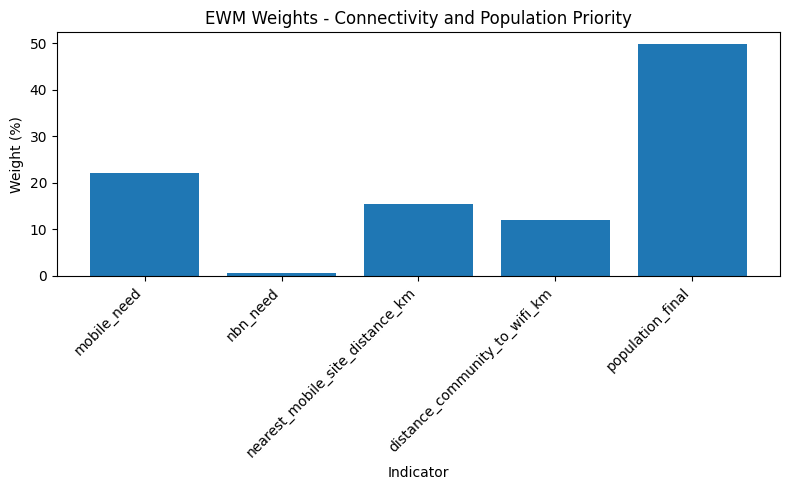

In [29]:
plt.figure(figsize=(8, 5))
plt.bar(weights2["Feature"], weights2["Weight_Percent"])
plt.title("EWM Weights - Connectivity and Population Priority")
plt.xlabel("Indicator")
plt.ylabel("Weight (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 27. Ranking 2 Results


In [30]:
ranking2_results = ranking2[
    [
        "priority_rank",
        "community_id",
        "community_name",
        "population_final",
        "mobile_need",
        "nbn_need",
        "nearest_mobile_site_distance_km",
        "distance_community_to_wifi_km",
        "priority_score"
    ]
]

ranking2_results.head(10)


,priority_rank,community_id,community_name,population_final,mobile_need,nbn_need,nearest_mobile_site_distance_km,distance_community_to_wifi_km,priority_score
0,1,16222,NHULUNBUY,3362.0,0,0,0.62,7.94,0.501029
1,2,362,MANINGRIDA,2956.0,0,1,0.93,82.50,0.466358
2,3,25070,BATTON HILL,2.0,1,1,141.08,214.83,0.438323
3,4,259,WOGYALA,40.0,1,1,100.89,294.89,0.421084
4,5,26,ORRTIPA-THURRA,62.0,1,1,127.83,140.63,0.413089
5,6,492,GALIWINKU,2582.0,0,1,0.21,47.14,0.400777
6,7,248,MUNGALAWURRU,15.0,1,1,64.54,304.62,0.380124
7,8,639,NITJPURRU,142.0,1,1,54.21,275.24,0.379869
8,9,279,ACACIA LARRAKIA,799.0,1,1,15.67,56.11,0.377128
9,10,858,MURRANJI,4.0,1,1,66.41,253.22,0.366956


## 28. Top 10 — Ranking 2


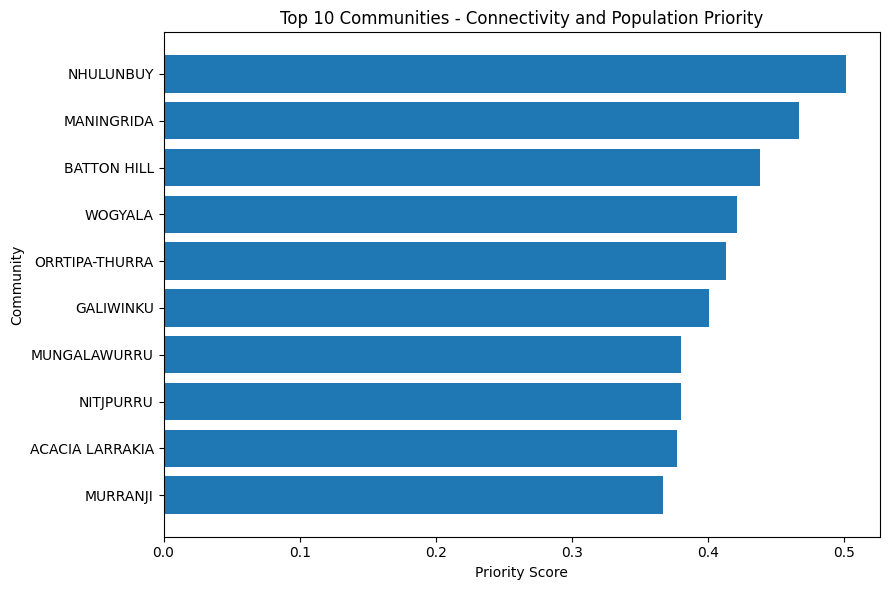

In [31]:
top10_ranking2 = ranking2_results.head(10).sort_values("priority_score")

plt.figure(figsize=(9, 6))
plt.barh(top10_ranking2["community_name"], top10_ranking2["priority_score"])
plt.title("Top 10 Communities - Connectivity and Population Priority")
plt.xlabel("Priority Score")
plt.ylabel("Community")
plt.tight_layout()
plt.show()


## 29. Compare EWM Weights

The rankings use different samples and independently calculated EWM weights, so their scores should not be directly compared.


In [32]:
weight_comparison = pd.merge(
    weights1[["Feature", "Weight_Percent"]],
    weights2[["Feature", "Weight_Percent"]],
    on="Feature",
    how="outer",
    suffixes=("_Ranking1", "_Ranking2")
)

weight_comparison


,Feature,Weight_Percent_Ranking1,Weight_Percent_Ranking2
0,distance_community_to_wifi_km,26.56,12.03
1,mobile_need,38.81,22.14
2,nbn_need,2.66,0.55
3,nearest_mobile_site_distance_km,31.97,15.46
4,population_final,NaN,49.83


## 30. Geographic Visualisation — Ranking 1


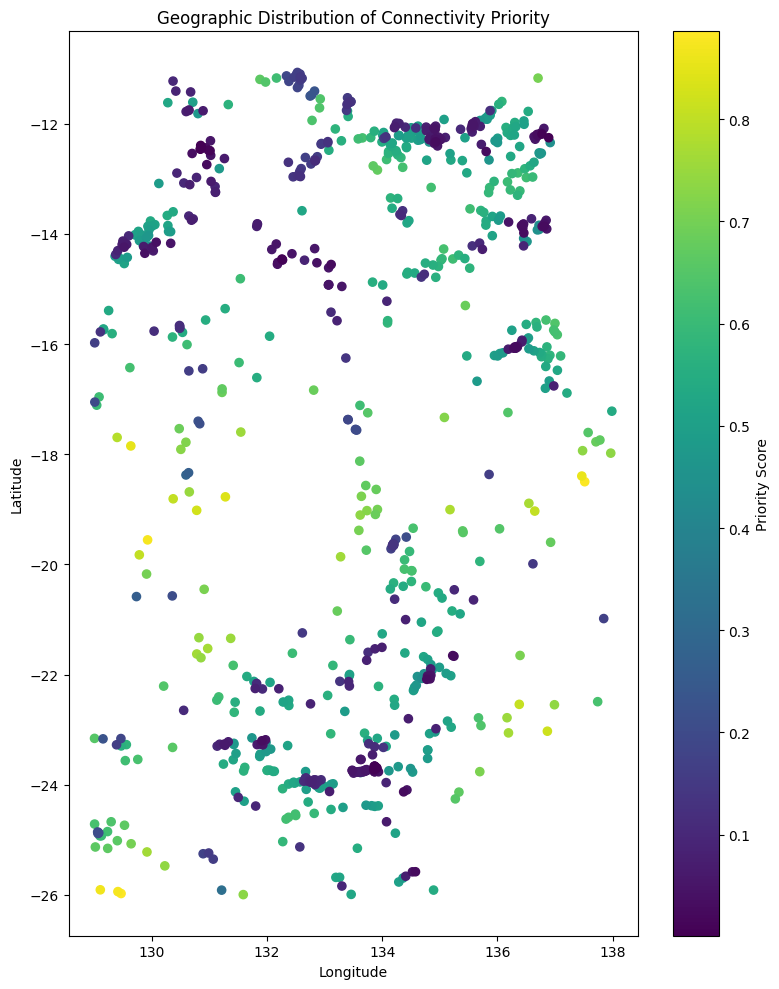

In [33]:
plt.figure(figsize=(8, 10))

scatter = plt.scatter(
    ranking1["community_longitude"],
    ranking1["community_latitude"],
    c=ranking1["priority_score"],
    s=35
)

plt.colorbar(scatter, label="Priority Score")
plt.title("Geographic Distribution of Connectivity Priority")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()


## 31. Geographic Visualisation — Ranking 2


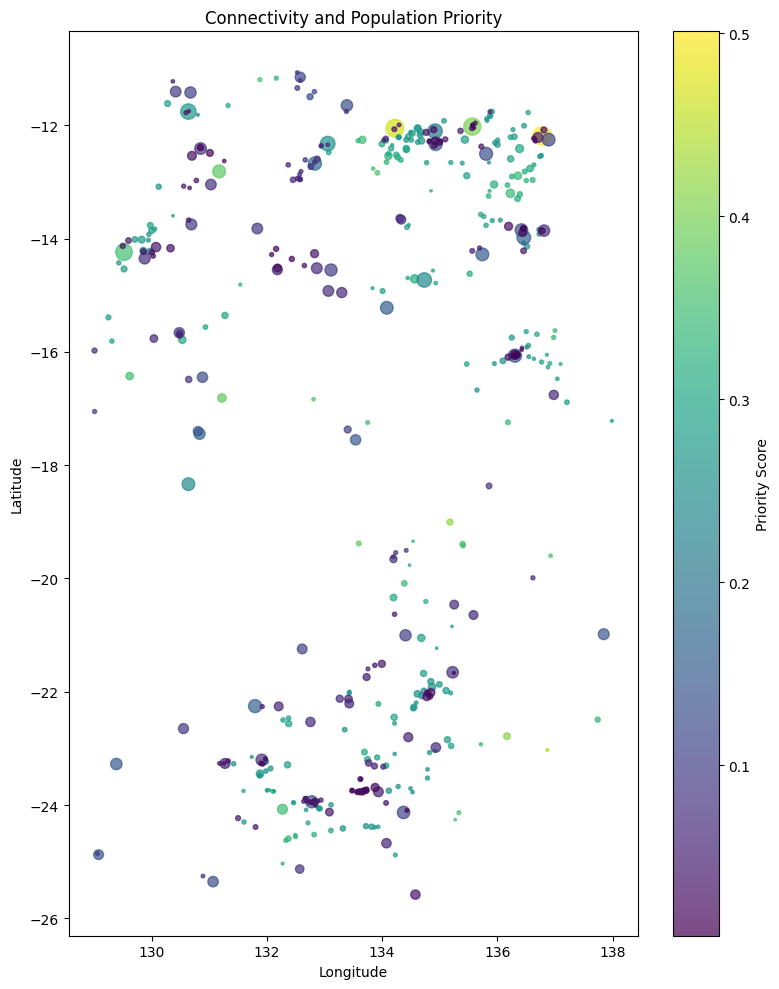

In [34]:
plt.figure(figsize=(8, 10))

scatter = plt.scatter(
    ranking2["community_longitude"],
    ranking2["community_latitude"],
    c=ranking2["priority_score"],
    s=np.sqrt(ranking2["population_final"]) * 3,
    alpha=0.7
)

plt.colorbar(scatter, label="Priority Score")
plt.title("Connectivity and Population Priority")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()


## 32. Population Data Availability


In [35]:
population_status = data[
    ["community_id", "community_name", "population_final"]
].copy()

population_status["population_status"] = np.where(
    population_status["population_final"].isna(),
    "Population unavailable",
    "Population available"
)

population_status["population_status"].value_counts()


population_status
Population available      468
Population unavailable    324
Name: count, dtype: int64

## 33. Final Summary


In [36]:
print("Total communities:", len(data))
print("Ranking 1:", len(ranking1_results))
print("Ranking 2:", len(ranking2_results))
print("Population unavailable:", data["population_final"].isna().sum())


Total communities: 792
Ranking 1: 792
Ranking 2: 468
Population unavailable: 324


## 34. Export Results


In [37]:
ranking1_results.to_csv(
    "ranking1_connectivity_priority.csv",
    index=False
)

weights1.to_csv(
    "ranking1_ewm_weights.csv",
    index=False
)

ranking2_results.to_csv(
    "ranking2_connectivity_population_priority.csv",
    index=False
)

weights2.to_csv(
    "ranking2_ewm_weights.csv",
    index=False
)

feature_summary.to_csv(
    "candidate_feature_summary.csv"
)

high_corr.to_csv(
    "high_correlation_features.csv",
    index=False
)

feature_selection.to_csv(
    "feature_selection.csv",
    index=False
)

population_status.to_csv(
    "population_availability.csv",
    index=False
)

print("All results exported successfully.")


All results exported successfully.
